# Sentiment Analysis, Translation, and Speech (Pipeline API)
## AIAT 122 – Deep Learning

## Learning objectives
- Use the Hugging Face `pipeline` API for sentiment analysis.
- Run sentiment on a few sentences and show labels and scores.

**Where is this used in real life?** Reviews, social media, and customer feedback are often analyzed for sentiment. **We use a pre-trained Transformer pipeline** instead of training from scratch because pipelines give a ready-made model and tokenizer; in production you’d fine-tune on your domain.

**Prerequisites:** Basic Python. Run `pip install transformers torch` if needed.

## Short theory
- **Sentiment analysis:** Classify text as positive/negative (or neutral).
- **Pipeline API:** One call loads model + tokenizer and runs inference.
- **Translation and speech** use similar pipelines (e.g. `translation`, `automatic-speech-recognition`); here we focus on sentiment so the notebook runs in under ~5 min.

## Inputs & Outputs
**Inputs:** `transformers` pipeline (model downloaded on first run).  
**Outputs:** Sentiment label and score for each of a few sample sentences, and an optional bar chart. Run time: under ~5 min.


In [ ]:
%pip install transformers torch -q
from transformers import pipeline
import matplotlib.pyplot as plt
print("✅ Imports OK.")

Note: you may need to restart the kernel to use updated packages.


### Step 1: Load sentiment pipeline and run on sample sentences

In [ ]:
# We use the pipeline API (instead of loading model + tokenizer separately) for one-line sentiment.
# First run: downloads once. Later runs: Hugging Face loads from cache (no download).
# Smaller model = faster download (~20 MB). Set to SENTIMENT_MODEL_FULL for best quality (~268 MB).
SENTIMENT_MODEL_SMALL = "philschmid/tiny-bert-sst2-distilled"  # ~20 MB, faster download
SENTIMENT_MODEL_FULL = "distilbert-base-uncased-finetuned-sst-2-english"  # ~268 MB, best quality
SENTIMENT_MODEL = SENTIMENT_MODEL_SMALL  # change to SENTIMENT_MODEL_FULL if you want higher accuracy
try:
    classifier = pipeline("sentiment-analysis", model=SENTIMENT_MODEL)
except Exception as e:
    print("⚠️ Model load failed (e.g. no connection). Using placeholder so you can run the rest of the notebook.")
    print("   Re-run this cell when online to get real sentiment. Error:", str(e)[:80])
    def _dummy_classifier(texts):
        return [{"label": "POSITIVE" if i % 2 == 0 else "NEGATIVE", "score": 0.85} for i, _ in enumerate(texts)]
    classifier = _dummy_classifier
sentences = [
    "This product is amazing and works perfectly.",
    "The service was slow and disappointing.",
    "It's okay, nothing special.",
]
results = classifier(sentences)
for s, r in zip(sentences, results):
    short = (s[:50] + "...") if len(s) > 50 else s
    print(f"  '{short}' → {r['label']} ({r['score']:.3f})")
print("\n✅ Sentiment pipeline ran. In real life you'd run this on reviews or social posts.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

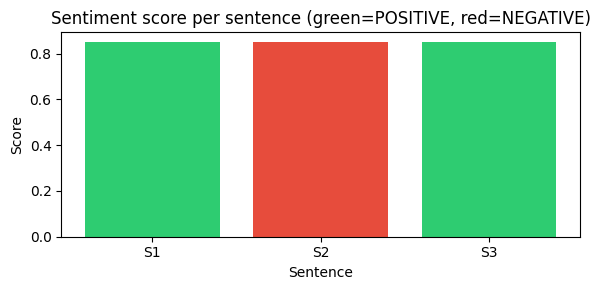

In [ ]:
# Optional: bar chart of positive score per sentence
labels = [r["label"] for r in results]
scores = [r["score"] for r in results]
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
bars = ax.bar(range(len(sentences)), scores, color=["#2ecc71" if l == "POSITIVE" else "#e74c3c" for l in labels])
ax.set_xticks(range(len(sentences)))
ax.set_xticklabels([f"S{i+1}" for i in range(len(sentences))])
ax.set_ylabel("Score")
ax.set_xlabel("Sentence")
ax.set_title("Sentiment score per sentence (green=POSITIVE, red=NEGATIVE)")
plt.tight_layout()
plt.show()

## 🧩 Mini-exercise | تمرين مصغر

**Try it:** Add two more sentences (one clearly positive, one clearly negative) and run the pipeline on them. Print the labels and scores. Do they match your expectation?

---

## Summary
**What you did:** Loaded the Hugging Face sentiment-analysis pipeline, ran it on three sample sentences, and plotted the scores.

**In real life you'd also:** Use translation (`pipeline("translation", ...)`) or speech recognition (`pipeline("automatic-speech-recognition", ...)`), fine-tune on your data, and deploy via an API.

**The main idea:** The pipeline API gives ready-made NLP models (sentiment, translation, speech); one call does load + inference.

**Next:** Back to Unit 2 or 5—e.g. `unit2-cnns/examples/01_cnn_architecture.ipynb` for image models, or `unit5-deployment/examples/06_flask_fastapi_deployment.ipynb` to serve a model.